<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="cognitiveclass.ai logo">
</center>


# Machine Learning Foundation

## Course 4, Part b: Distance and the Curse of Dimensionality DEMO


Estimated time needed: **45** minutes


In [1]:
# Suppress warnings to keep the output clean
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# Import necessary libraries: seaborn for visualizations, pandas for data manipulation, and numpy for numerical operations
import seaborn as sns, pandas as pd, numpy as np

In [2]:
# Import pyplot from matplotlib for plotting and numpy for numerical operations
from matplotlib import pyplot as plt
import numpy as np

# Curse of Dimensionality

### DEMO objectives:
* Gain understanding of why observations are far apart in high-dimensional space
* See an example of how adding dimensions degrades model performance for classification
* Learn how to fight the curse of dimensionality in your modeling projects

-----

### In high-dimensional space, points tend to be far apart.
This impacts data analysis. Intuitively, clustering is difficult when points are far away from each other: If my next nearest neighbor is very far away, does it still make sense to call it my neighbor? This notebook will show why high-dimensional space leads to sparse data.


### A circle inside a square

Let's start by drawing a unit circle inside of a square.


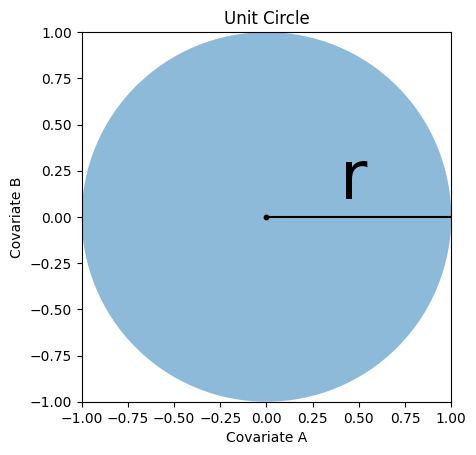

In [3]:
# Define a function to create and display a unit circle within a square
def make_circle(point=0):
    # Get the current figure and add a subplot with equal aspect ratio
    fig = plt.gcf()
    ax = fig.add_subplot(111, aspect='equal')
    # Add a unit circle to the plot
    fig.gca().add_artist(plt.Circle((0,0),1,alpha=.5))
    # Plot the origin (center of the circle)
    ax.scatter(0,0,s=10,color="black")
    # Plot a line segment from the origin to the edge of the circle to represent the radius
    ax.plot(np.linspace(0,1,100),np.zeros(100),color="black")
    # Add text label for the radius
    ax.text(.4,.1,"r",size=48)
    # Set the limits for the x and y axes
    ax.set_xlim(left=-1,right=1)
    ax.set_ylim(bottom=-1,top=1)
    # Add labels to the axes
    plt.xlabel("Covariate A")
    plt.ylabel("Covariate B")
    # Add a title to the plot
    plt.title("Unit Circle")

    # If point is true, add a 'far away' point and label
    if point:
        ax.text(.55,.9,"Far away",color="purple")
        ax.scatter(.85,.85,s=10,color="purple")
    else:
        # Display the plot
        plt.show()

# Call the function to create the initial circle plot
make_circle()

Each axis is a different covariate. Imagine we've standard scaled our data, so they're centered on zero. This means that the average for each covariate is now zero, or the center of our circle. Points that our outside the unit circle would be harder to classify because the values of their covariates are far from the mean.


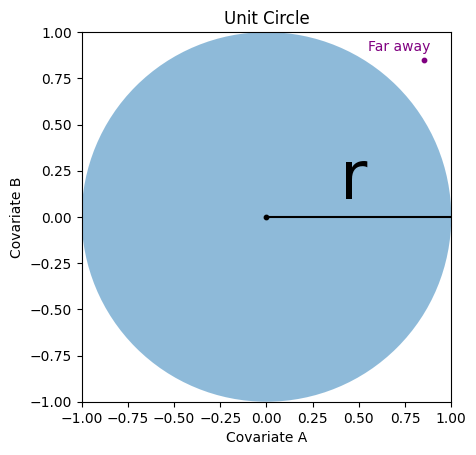

In [4]:
# Call the make_circle function with point=1 to add a 'far away' point to the plot
make_circle(1)

### How much of the square is outside the circle? And the cube outside the sphere, etc.

We've concluded that our purple point above would be hard to classify because it's far away from the rest of our observations. But what percentage of our points in the square are outside of the circle, and thus "far away"? Let's do some math!

Since the square has length $2r$ and area $(2r)^2$, the percentage of the square outside the circle is:  1 - $\frac {\pi r^2} {(2r)^2} = 1 - \frac \pi 4$ = ~ 21%

But what about a cube? To illustrate, we will use [matplotlib's 3-D axis](https://matplotlib.org/3.2.1/api/_as_gen/mpl_toolkits.mplot3d.axes3d.Axes3D.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) which allows the '3d' projection, as well as the [itertools](https://docs.python.org/3/library/itertools.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) library, which offers a number of efficient tools for looping and combining lists. We will use the [product](https://docs.python.org/2/library/itertools.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01#itertools.product) (cartesian product) and [combinations](https://docs.python.org/2/library/itertools.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01#itertools.combinations) (unique subsequences) functions.


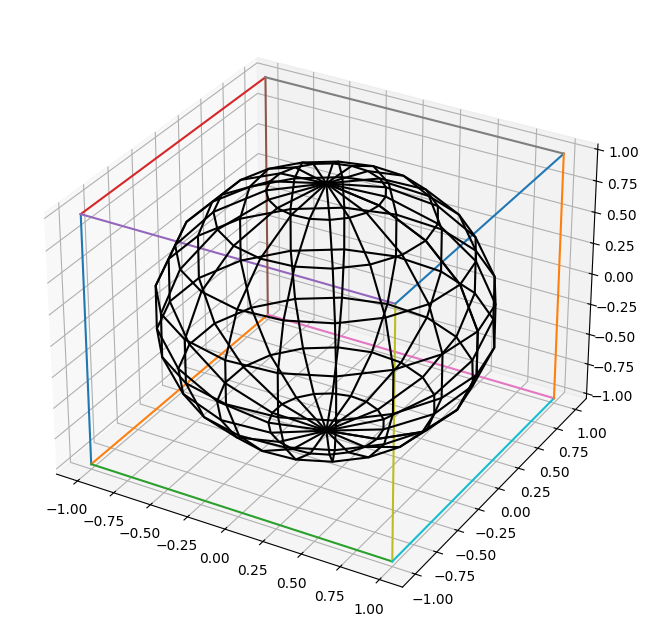

In [6]:
# Import necessary libraries for 3D plotting and combinations
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from itertools import product, combinations

# Create a new figure with a specified size
fig = plt.figure(figsize=(8,8))
# Add a 3D subplot to the figure
ax = fig.add_subplot(projection='3d')
#ax.set_aspect("equal") # This line is commented out

# Define the range for the cube's vertices
r = [-1, 1]
# Iterate through combinations of vertices to draw the edges of the cube
for s, e in combinations(np.array(list(product(r,r,r))), 2):
    if np.sum(np.abs(s-e)) == r[1]-r[0]:
        ax.plot3D(*zip(s,e))

# Define parameters for drawing the sphere
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
# Calculate x, y, and z coordinates for the sphere
x=np.cos(u)*np.sin(v)
y=np.sin(u)*np.sin(v)
z=np.cos(v)
# Plot the wireframe of the sphere
ax.plot_wireframe(x, y, z, color="black");

The volume of the sphere is given by the forumula: $\frac{4}{3} \pi r^3$, and since the cube has a radius of $2r$, it has volume $(2r)^3$.

This allows us to calculate the percent of the cube's volume that's outside of the sphere: 1- $\frac {\frac 4 3 \pi r^3} {(2r)^3} = 1 - \frac \pi 6$ = ~ 48%

### Can we generalize to more than three dimensions?

Let's draw a bunch of random points from a 0-1 distribution, then measure how far away from the origin they are.


In [7]:
# Draw a sample of data in two dimensions
sample_data = np.random.sample((5,2))
print("Sample data:\n", sample_data, '\n')

# Define a function to measure the Euclidean distance of each point from the origin
def norm(x):
    ''' Measure the distance of each point from the origin.

    Input: Sample points, one point per row
    Output: The distance from the origin to each point
    '''
    return np.sqrt( (x**2).sum(1) ) # np.sum() sums an array over a given axis

# Define a function to determine if a point is inside the unit ball (circle in 2D)
def in_the_ball(x):
    ''' Determine if the sample is in the circle.

    Input: Sample points, one point per row
    Output: A boolean array indicating whether the point is in the ball
    '''
    return norm(x) < 1 # If the distance measure above is <1, we're inside the ball


# Iterate through the calculated norms and check if the points are in the ball
for x, y in zip(norm(sample_data),in_the_ball(sample_data)):
    print("Norm = ", x.round(2), "; is in circle? ", y)

Sample data:
 [[0.48160513 0.81228845]
 [0.8889417  0.36973707]
 [0.96583279 0.08491035]
 [0.77106845 0.20578823]
 [0.7964913  0.07907855]] 

Norm =  0.94 ; is in circle?  True
Norm =  0.96 ; is in circle?  True
Norm =  0.97 ; is in circle?  True
Norm =  0.8 ; is in circle?  True
Norm =  0.8 ; is in circle?  True


Can we generalize beyond two dimensions?


In [8]:
# Define a function to estimate the percentage of the n-cube that is within the n-ball for a given dimension
def what_percent_of_the_ncube_is_in_the_nball(d_dim,
                                              sample_size=10**4):
    # Define the shape of the sample data
    shape = sample_size,d_dim
    # Generate random samples and calculate the mean percentage of points within the ball over multiple iterations
    data = np.array([in_the_ball(np.random.sample(shape)).mean()
                     for iteration in range(100)])
    # Return the mean percentage
    return data.mean()

# Define a range of dimensions to test
dims = range(2,15)
# Calculate the percentage of the n-cube in the n-ball for each dimension
data = np.array(list(map(what_percent_of_the_ncube_is_in_the_nball,dims)))

# Print the results for each dimension
for dim, percent in zip(dims,data):
    print("Dimension = ", dim, "; percent in ball = ", percent)

Dimension =  2 ; percent in ball =  0.7853419999999999
Dimension =  3 ; percent in ball =  0.523374
Dimension =  4 ; percent in ball =  0.30743899999999996
Dimension =  5 ; percent in ball =  0.16464399999999998
Dimension =  6 ; percent in ball =  0.080678
Dimension =  7 ; percent in ball =  0.037124
Dimension =  8 ; percent in ball =  0.015896
Dimension =  9 ; percent in ball =  0.006502
Dimension =  10 ; percent in ball =  0.002525
Dimension =  11 ; percent in ball =  0.0009010000000000001
Dimension =  12 ; percent in ball =  0.000299
Dimension =  13 ; percent in ball =  0.000104
Dimension =  14 ; percent in ball =  3.7e-05


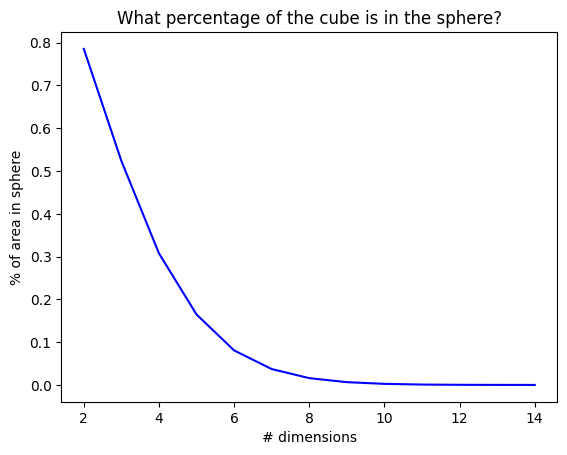

In [9]:
# Plot the calculated percentages of the n-cube in the n-ball against the number of dimensions
plt.plot(dims, data, color='blue')
# Label the x-axis
plt.xlabel("# dimensions")
# Label the y-axis
plt.ylabel("% of area in sphere")
# Add a title to the plot
plt.title("What percentage of the cube is in the sphere?")
# Display the plot
plt.show()

## Check for understanding

What happens to the percentage of the area in the sphere as we increase the number of dimensions? What does this mean about how the dispersion of our data?

---


### Measuring the distance from the center of the cube to the nearest point

Let's continue with our drawing of random points in the cube. This time, we'll draw a bunch of points, then measure the distance of all the points to the center of the cube to see how close the closest point is to the center.

If we find out that the closest point is far from the center in high dimensions, that gives us more evidence that increasing dimensions will make it harder to classify our data properly.


In [10]:
# Define a function to get the minimum distance from the origin for a sample of points in a given dimension
def get_min_distance(dimension, sample_size=10**3):
    ''' Sample some random points and find the closet
    of those random points to the center of the data '''
    # Generate random points centered around the origin
    points = np.random.sample((sample_size,dimension))-.5   # centering our data
    # Return the minimum norm (distance from origin) among the sampled points
    return np.min(norm(points))

# Define a function to estimate the closest point to the origin for a given dimension by repeating the sampling process
def estimate_closest(dimension):
    ''' For a given dimension, take a random sample in that dimension and then find
        that sample's closest point to the center of the data.
        Repeat 100 times for the given dimension and return the min/max/mean
        of the distance for the nearest point. '''
    # Repeat the get_min_distance function 100 times for the given dimension
    data = np.array([get_min_distance(dimension) for _ in range(100)])
    # Return the mean, minimum, and maximum of the minimum distances found
    return data.mean(), data.min(), data.max()

# Calculate the minimum distance statistics for dimensions from 2 to 99
dims = range(2,100)
min_distance_data = np.array(list(map(estimate_closest,dims)))

# Test the estimate_closest function for dimension 6 and print the result
print("For dimension 6: ", estimate_closest(6))

For dimension 6:  (np.float64(0.22751474350751344), np.float64(0.13291549532566507), np.float64(0.3135973243157301))


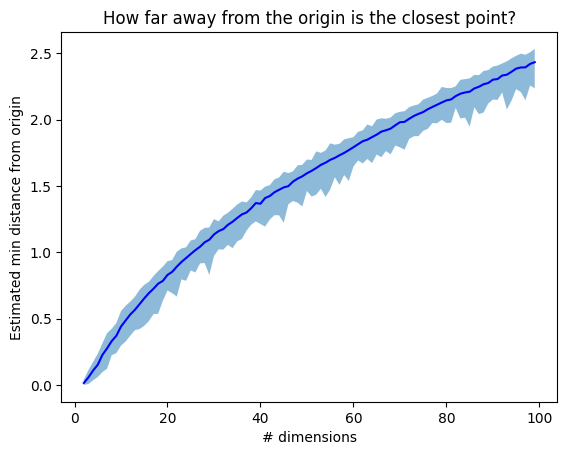

In [11]:
# Plot the mean, min, and max of the estimated minimum distance from the origin against the number of dimensions
plt.plot(dims,min_distance_data[:,0], color='blue')
# Fill the area between the minimum and maximum distance lines to show the range
plt.fill_between(dims, min_distance_data[:,1], min_distance_data[:,2],alpha=.5)
# Label the x-axis
plt.xlabel("# dimensions")
# Label the y-axis
plt.ylabel("Estimated min distance from origin")
# Add a title to the plot
plt.title("How far away from the origin is the closest point?");

## Check for understanding

What would we have to do to get similar density of points as the low dimensions if we wanted to use higher dimensions of data?

---


### How to fight the curse of dimensionality

The curse of dimensionality is a common hurdle in real-world predictive modeling. We've already seen this in our bag-of-words approach to NLP. How can we create good models in cases where our data is of high dimensionality?

* Feature selection: Use domain knowledge to reduce the number of features included in the model
* Feature extraction: Use dimensionality reduction techniques (e.g. PCA) to transform the raw data into a lower number of features that preserve (most of) the variability in the data

We'll talk more about PCA next.


## How does high dimensionality affect model performance?

We'll test model performance (classification accuracy) by creating some random data for classification, one set with a low number of features and another with a very high number of features. We'll then compare their performance using the same classification algorithm.


In [12]:
# Import necessary libraries from scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.preprocessing import StandardScaler # For standardizing features
from sklearn.datasets import make_classification # For generating synthetic classification datasets
from sklearn.tree import DecisionTreeClassifier # For using a Decision Tree Classifier model

In [13]:
# Create a synthetic classification dataset with 2 features
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=2)
# Create a RandomState object for reproducibility
rng = np.random.RandomState(2)
# Add uniform noise to the features
X += 2 * rng.uniform(size=X.shape)

# Standardize the features
X = StandardScaler().fit_transform(X)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=42)

In [14]:
# Initialize a Decision Tree Classifier model
DT =  DecisionTreeClassifier()
# Train the model using the training data
DT.fit(X_train, y_train)
# Evaluate the model's accuracy on the test data
score = DT.score(X_test, y_test)

In [15]:
# Print the accuracy score of the two-feature classifier
print("Score from two-feature classifier: ", score)

Score from two-feature classifier:  0.875


In [16]:
# Create a synthetic classification dataset with 200 features
X, y = make_classification(n_features=200, n_redundant=0, n_informative=200,
                           random_state=1, n_clusters_per_class=2)
# Create a RandomState object for reproducibility
rng = np.random.RandomState(2)
# Add uniform noise to the features
X += 2 * rng.uniform(size=X.shape)

# Standardize the features
X = StandardScaler().fit_transform(X)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=42)

# Initialize a Decision Tree Classifier model
DT =  DecisionTreeClassifier()
# Train the model using the training data
DT.fit(X_train, y_train)
# Evaluate the model's accuracy on the test data
score = DT.score(X_test, y_test)

In [17]:
# Print the accuracy score of the 200-feature classifier
print("Score from 200-feature classifier: ", score)

Score from 200-feature classifier:  0.525


Here we see that adding additional features, even if informative, can lead to worse model performance (due to increased overfitting of training data.


### Comparing accuracy of classification against number of features

Let's see what happens if we keep adding features to our classification problem. We'll hold the number of classes at three in order to see how the curse of dimensionality hurts our model performance.


In [18]:
# Initialize an empty list to store accuracy scores
scores = []

# Define the increment and maximum number of features
increment, max_features = 50, 4000

# Iterate through different numbers of features
for num in np.linspace(increment, max_features, increment, dtype='int'):

    # Create a synthetic classification dataset with varying number of features and 3 classes
    X, y = make_classification(n_features=num, n_redundant=0,
                               random_state=1, n_clusters_per_class=1, n_classes = 3)
    # Create a RandomState object for reproducibility
    rng = np.random.RandomState(2)
    # Add uniform noise to the features
    X += 2 * rng.uniform(size=X.shape)

    # Standardize the features
    X = StandardScaler().fit_transform(X)
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=42)

    # Initialize a Decision Tree Classifier model
    DT =  DecisionTreeClassifier()
    # Train the model
    DT.fit(X_train, y_train)
    # Evaluate and store the accuracy score
    scores.append( DT.score(X_test, y_test) )

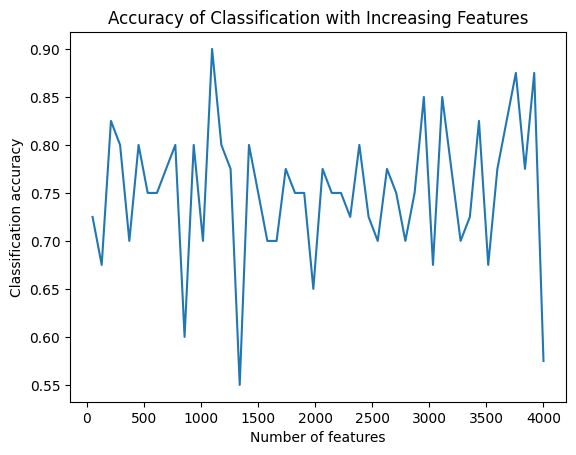

In [19]:
# Plot the accuracy scores against the number of features
plt.plot(np.linspace(increment, max_features, increment, dtype='int'),scores)
# Add a title to the plot
plt.title("Accuracy of Classification with Increasing Features")
# Label the x-axis
plt.xlabel("Number of features")
# Label the y-axis
plt.ylabel("Classification accuracy");

As we can see from the chart, adding features can lead to reductions in accuracy -- in this example accuracy is highly volatile in the number of features, and increasing features can reduce accuracy. Additionally, in our example, we specified that none of the features are redundnant (`n_redundant=0`). In practice, the situation is often worse as several of the features may be either redundant or not relevant. For example, if we are predicting customer churn using a variety of customer characteristics, we may have collected extensive data for each customer across many dimensions. This is an example of high-dimensional, which can make it difficult to apply unsupervised learning methods directly and potentially to lead to issues with the curse of dimensionality.

---
### Machine Learning Foundation (C) 2020 IBM Corporation
